# Comparación de seis algoritmos de agrupamiento
### Segmentación de compatibilidad proveedor–licitación · SERCOP (OCDS)
**Proyecto final de Inteligencia Artificial — ESPOL, CCPG1044, Grupo #3**

Este notebook implementa y ejecuta el protocolo de comparación fijado de antemano.
No rediseña el análisis: sólo lo ejecuta y reporta los resultados reales.

**Decisiones registradas antes de modelar**

| Punto | Decisión |
|---|---|
| Datos | `data/{2024,2025,2026}.jsonl.gz` en disco. Ninguna API consumida. |
| Proveedor consultante | `EC-RUC-1790475689001-5192` — ROCHE ECUADOR S.A. (elegido tras el diagnóstico de `scripts/diag_proveedor.py`) |
| Historial del proveedor | Construido **sólo** con procesos `tender.status = "complete"`, para no filtrar información desde las filas que se agrupan |
| Semilla | `random_state = 42` en todo |
| `scikit-learn-extra` | No importa con numpy 2.x → PAM implementado sobre la matriz de Gower |

In [1]:
import os, sys, json, time, gc, warnings, platform
import numpy as np
import pandas as pd

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(BASE, "scripts"))
import nucleo as N

RES = os.path.join(BASE, "resultados")
os.makedirs(RES, exist_ok=True)
SEED = 42
np.random.seed(SEED)

import sklearn, scipy, matplotlib, kmodes
VERSIONES = {
    "python": platform.python_version(),
    "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__, "kmodes": kmodes.__version__,
    "matplotlib": matplotlib.__version__, "so": f"{platform.system()} {platform.release()}",
}
for k, v in VERSIONES.items():
    print(f"{k:>14}: {v}")

try:
    from sklearn_extra.cluster import KMedoids
    SKEXTRA = "OK"
except Exception as e:
    SKEXTRA = f"{type(e).__name__}: {e}"
print(f"\nscikit-learn-extra -> {SKEXTRA}")

cron = N.Cronometro()

        python: 3.11.15
         numpy: 2.4.6
        pandas: 3.0.5
         scipy: 1.17.1
  scikit-learn: 1.9.0
        kmodes: 0.12.2
    matplotlib: 3.11.1
            so: Windows 10

scikit-learn-extra -> ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


## PASO 0 — Inventario del corte local

Cifras producidas por `scripts/construir_matriz.py` sobre los tres `.jsonl.gz`.

In [2]:
inv = json.load(open(os.path.join(RES, "paso0_inventario.json"), encoding="utf-8"))

print(f"Líneas leídas ................ {inv['lineas_leidas']:,}")
print(f"ocid únicos .................. {inv['ocid_unicos']:,}  (duplicados colapsados: {inv['duplicados_colapsados']})")
print()
print("Reparto por tender.status:")
for k, v in sorted(inv["status"].items(), key=lambda kv: -kv[1]):
    print(f"   {k:<12} {v:>7,}")
print()
print(f"(a) PROCESOS ACTIVOS ......... {inv['activos_tender_status']:,}")
print(f"    umbral del enunciado ..... 1.000  ->  {'SE CONTINÚA' if inv['activos_tender_status'] >= 1000 else 'DETENER'}")
print()
print("Descartes por datos faltantes (sin imputar):")
for k, v in inv["descartes_por_falta_de_datos"].items():
    print(f"   {k:<28} {v:>6,}")
print()
m = inv["matriz"]
print(f"(b) MATRIZ ................... {m['filas']:,} filas x {m['columnas_semanticas']} columnas")
print(f"    codificada (one-hot) ..... {m['filas']:,} x {m['columnas_codificadas_onehot']}  ({m['modalidades_distintas']} modalidades)")
print()
g = inv["gower_n2"]
print(f"(c) MATRIZ DE GOWER (n^2) .... {g['celdas']:,} celdas")
print(f"    float64 .................. {g['float64_GB']} GB")
print(f"    float32 (la que se usa) .. {g['float32_GB']} GB")
print(f"    condensada float64 ....... {g['condensada_float64_GB']} GB")
print()
p = inv["proveedor_consultante"]
print(f"Proveedor consultante: {p['nombre']}  ({p['id']})")
print(f"   procesos históricos={p['procesos_historicos']}  provincia={p['provincia']}  "
      f"CPC distintos={p['cpc_distintos']}  mediana monto=${p['mediana_monto_historico']:,.2f}")

Líneas leídas ................ 90,076
ocid únicos .................. 90,076  (duplicados colapsados: 0)

Reparto por tender.status:
   complete      72,846
   active        14,660
   (sin dato)     2,570

(a) PROCESOS ACTIVOS ......... 14,660
    umbral del enunciado ..... 1.000  ->  SE CONTINÚA

Descartes por datos faltantes (sin imputar):
   sin_provincia_comprador         304
   sin_items                       508

(b) MATRIZ ................... 13,848 filas x 6 columnas
    codificada (one-hot) ..... 13,848 x 24  (19 modalidades)

(c) MATRIZ DE GOWER (n^2) .... 191,767,104 celdas
    float64 .................. 1.429 GB
    float32 (la que se usa) .. 0.714 GB
    condensada float64 ....... 0.714 GB

Proveedor consultante: ROCHE ECUADOR S.A.  (EC-RUC-1790475689001-5192)
   procesos históricos=87  provincia=PICHINCHA  CPC distintos=24  mediana monto=$34,788.00


In [3]:
df = N.cargar_matriz()
print(f"Matriz cargada: {df.shape}")
display(df[N.NUMERICAS + [N.CATEGORICA]].head(8))
display(df[N.NUMERICAS].describe(percentiles=[.5, .9, .99]).T)
print("\nModalidades (categórica única, convenios de Catálogo Electrónico colapsados):")
print(df[N.CATEGORICA].value_counts().to_string())

Matriz cargada: (13848, 13)


,distancia_geografica_km,cpc_match_score,sim_semantica_tfidf,desviacion_presupuesto,actividad_cpc_comprador,modalidad_contratacion
0,0.000000,0.0,0.011640,-2.045002,1.0,Contratacion directa
1,0.000000,0.0,0.023901,-0.214529,1.0,Contratacion directa
2,0.000000,0.0,0.011688,-1.959864,1.0,Contratacion directa
3,302.451621,0.0,0.014489,-1.767814,0.0,Contratacion directa
4,302.451621,0.0,0.000000,-0.260862,0.0,Contratacion directa
5,302.451621,0.0,0.017003,0.214871,0.0,Contratacion directa
6,302.451621,0.0,0.000000,0.103821,0.0,Contratacion directa
7,302.451621,0.0,0.000000,-0.779466,0.0,Contratacion directa


,count,mean,std,min,50%,90%,99%,max
distancia_geografica_km,13848.0,182.472885,163.224542,0.000000,183.480219,342.966619,430.147484,1313.541119
cpc_match_score,13848.0,0.223055,0.361483,0.000000,0.000000,1.000000,1.000000,1.000000
sim_semantica_tfidf,13848.0,0.022222,0.048183,0.000000,0.004648,0.062827,0.267270,0.494941
desviacion_presupuesto,13848.0,0.264672,1.380464,-5.946197,0.103562,2.144540,4.090009,7.370932
actividad_cpc_comprador,13848.0,1.485774,4.378638,0.000000,0.000000,5.000000,16.000000,56.000000



Modalidades (categórica única, convenios de Catálogo Electrónico colapsados):
modalidad_contratacion
Subasta Inversa Electrónica                              7990
Menor Cuantía                                            1885
Contratacion directa                                      981
Cotización                                                825
Bienes y Servicios únicos                                 549
Contratos entre Entidades Públicas o sus subsidiarias     329
Comunicación Social – Contratación Directa                317
Licitación de Seguros                                     282
Repuestos o Accesorios                                    183
Licitación                                                178
Obra artística, científica o literaria                    138
Lista corta                                               130
Transporte de correo interno o internacional               19
Asesoría y Patrocinio Jurídico                             14
Concurso publico              

## Pre-procesamiento único

Los seis algoritmos reciben exactamente la misma matriz y el mismo pre-procesamiento.

- `log(1+x)` sobre los montos: ya incorporado en `desviacion_presupuesto`
  = `log1p(monto_proceso) − log1p(mediana_histórica_del_proveedor)`.
- Estandarización (z-score) de las cinco numéricas → usada por K-Means, K-Prototypes y GMM.
- `modalidad_contratacion` es la única categórica; one-hot para K-Means/GMM y nativa para K-Prototypes.
- Gower normaliza por **rango**, no por z-score: recibe las numéricas crudas (es su definición).

In [4]:
with cron("preprocesamiento"):
    num, num_std, cat, X_cod, cols_cod, cat_nombres = N.preprocesar(df)
n = len(df)
print(f"n = {n:,}")
print(f"numéricas crudas      {num.shape}   (para Gower)")
print(f"numéricas z-score     {num_std.shape}  media={num_std.mean():.2e} std={num_std.std():.4f}")
print(f"matriz codificada     {X_cod.shape}  (5 numéricas z + {len(cat_nombres)} one-hot)")
print(f"modalidades           {len(cat_nombres)}")

n = 13,848
numéricas crudas      (13848, 5)   (para Gower)
numéricas z-score     (13848, 5)  media=1.72e-17 std=1.0000
matriz codificada     (13848, 24)  (5 numéricas z + 19 one-hot)
modalidades           19


## Árbitro único: matriz de distancias de Gower

Una sola matriz, compartida por todos. La silueta se evalúa **siempre** sobre ella con
`metric='precomputed'`, aunque cada algoritmo se ajuste en el espacio que le corresponde.
Sin ese árbitro común las siluetas no serían comparables.

Distancia = promedio simple de las 6 variables: numéricas `|xi−xj|/rango`, categórica `0/1`.
Se guarda en **float32** (0.71 GB en vez de 1.43 GB) por la memoria disponible en la máquina.

In [5]:
with cron("gower"):
    D = N.gower_matrix(num, cat)
print(f"D: {D.shape}  dtype={D.dtype}  {D.nbytes/1024**3:.3f} GB  ({cron.t['gower']} s)")
print(f"   min={D.min():.4f}  max={D.max():.4f}  media={D.mean():.4f}  diagonal={np.abs(np.diag(D)).max():.1e}")
print(f"   simétrica: {np.allclose(D[:500,:500], D[:500,:500].T)}")

D: (13848, 13848)  dtype=float32  0.714 GB  (3.81 s)
   min=0.0000  max=0.8065  media=0.2201  diagonal=0.0e+00
   simétrica: True


## Evaluador común

- **Silueta**: sobre Gower, `metric='precomputed'`. Excluye el ruido (−1) cuando lo hay.
- **Davies-Bouldin / Calinski-Harabasz**: sobre la **matriz codificada** (euclidiana). Sus
  implementaciones no aceptan matriz precalculada — quedan como criterio **secundario**.
- **Cobertura**: % de procesos asignados a un grupo real.

In [6]:
RESULTADOS = []       # filas de la tabla 6
ETIQUETAS = {}        # nombre -> etiquetas del ajuste final
CODO = {}             # nombre -> {k: W(k)}
DETALLE = {}          # notas por algoritmo

def evaluar(nombre, etq, k_reportado, guardar=True, nota=""):
    sil, n_usados, n_grupos = N.silueta_gower(D, etq)
    db, ch = N.db_ch(X_cod, etq)
    cob = N.cobertura(etq)
    fila = {
        "Algoritmo": nombre,
        "k usado/obtenido": k_reportado,
        "Silueta (Gower)": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
        "Cobertura": cob,
        "n evaluados (silueta)": n_usados,
        "Nota": nota,
    }
    if guardar:
        RESULTADOS.append(fila)
        ETIQUETAS[nombre] = np.asarray(etq)
    return fila

def barrer_k(nombre, fit_fn, ks=range(3, 11)):
    # Barre k y devuelve (df_barrido, mejor_k, mejor_etiquetas) por silueta sobre Gower.
    filas, etqs = [], {}
    CODO[nombre] = {}
    for k in ks:
        t0 = time.time()
        etq = fit_fn(k)
        dt = time.time() - t0
        sil, nu, ng = N.silueta_gower(D, etq)
        w = N.dispersion_intra(D, etq)
        CODO[nombre][k] = w
        filas.append({"k": k, "Silueta (Gower)": sil, "W(k) intra": w,
                      "grupos": ng, "seg": round(dt, 1)})
        etqs[k] = etq
        print(f"   k={k}  silueta={sil:.4f}  W={w:8.1f}  ({dt:.1f}s)")
        gc.collect()
    t = pd.DataFrame(filas)
    mejor_k = int(t.loc[t["Silueta (Gower)"].idxmax(), "k"])
    return t, mejor_k, etqs[mejor_k]

## Candidato 1 — K-Prototypes (`kmodes`)

`gamma` automático, `init='Cao'`, `n_init=10`. Barrido k = 3…10.

In [7]:
from kmodes.kprototypes import KPrototypes

Xkp = np.hstack([num_std.astype(object), cat.reshape(-1, 1).astype(object)])
IDX_CAT = [num_std.shape[1]]
avisos_kp = []

def fit_kproto(k, X=Xkp, idx=None):
    with warnings.catch_warnings(record=True) as ws:
        warnings.simplefilter("always")
        mdl = KPrototypes(n_clusters=k, init="Cao", n_init=10, gamma=None,
                          random_state=SEED, n_jobs=1, verbose=0)
        etq = mdl.fit_predict(X, categorical=IDX_CAT)
        for w in ws:
            msg = str(w.message)
            if msg not in avisos_kp:
                avisos_kp.append(msg)
    fit_kproto.ultimo = mdl
    return etq

print("K-Prototypes:")
with cron("kprototypes_barrido"):
    tab_kp, k_kp, etq_kp = barrer_k("K-Prototypes", fit_kproto)
print(f"\ngamma automático del último ajuste: {fit_kproto.ultimo.gamma:.4f}")
for a in avisos_kp:
    print("AVISO kmodes:", a)
display(tab_kp)
print(f"Mejor k por silueta sobre Gower: {k_kp}")

K-Prototypes:


   k=3  silueta=0.2022  W=  1119.3  (64.2s)


   k=4  silueta=0.1593  W=  1109.0  (57.0s)


   k=5  silueta=0.1430  W=  1092.6  (55.3s)


   k=6  silueta=0.1220  W=  1053.6  (65.4s)


...

   k=8  silueta=0.1169  W=  1023.4  (151.1s)


   k=9  silueta=0.1069  W=  1022.3  (107.0s)


   k=10  silueta=0.0971  W=  1003.5  (123.7s)

gamma automático del último ajuste: 0.5000


,k,Silueta (Gower),W(k) intra,grupos,seg
0,3,0.202237,1119.250573,3,64.2
1,4,0.159315,1108.993081,4,57.0
2,5,0.142968,1092.584563,5,55.3
3,6,0.121957,1053.586634,6,65.4
4,7,0.123122,1041.579692,7,97.7
5,8,0.116946,1023.352783,8,151.1
6,9,0.106898,1022.274402,9,107.0
7,10,0.097089,1003.458476,10,123.7


Mejor k por silueta sobre Gower: 3


In [8]:
nota_kp = f"gamma auto={fit_kproto.ultimo.gamma:.4f}; init=Cao"
if any("n_init" in a for a in avisos_kp):
    nota_kp += "; kmodes forzó n_init=1 (Cao es determinista)"
evaluar("K-Prototypes", etq_kp, k_kp, nota=nota_kp)
print(nota_kp)
print("Tamaño de grupos:", np.bincount(etq_kp))

gamma auto=0.5000; init=Cao
Tamaño de grupos: [7237 4343 2268]


## Candidato 2 — K-Means

One-hot de la modalidad, `k-means++`, `n_init=10`. Se ajusta sobre la matriz codificada;
la silueta se mide sobre Gower.

In [9]:
from sklearn.cluster import KMeans

def fit_kmeans(k, X=None):
    X = X_cod if X is None else X
    return KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED).fit_predict(X)

print("K-Means:")
with cron("kmeans_barrido"):
    tab_km, k_km, etq_km = barrer_k("K-Means", fit_kmeans)
display(tab_km)
print(f"Mejor k por silueta sobre Gower: {k_km}")
evaluar("K-Means", etq_km, k_km, nota="one-hot modalidad; k-means++; n_init=10")
print("Tamaño de grupos:", np.bincount(etq_km))

K-Means:


   k=3  silueta=0.2071  W=  1116.5  (1.7s)


   k=4  silueta=0.2055  W=  1107.2  (0.1s)


   k=5  silueta=0.2156  W=  1093.6  (0.1s)


   k=6  silueta=0.1582  W=  1076.9  (0.1s)


...

   k=9  silueta=0.1073  W=   979.0  (0.1s)


   k=10  silueta=0.1630  W=   812.1  (0.1s)


,k,Silueta (Gower),W(k) intra,grupos,seg
0,3,0.207109,1116.495295,3,1.7
1,4,0.205460,1107.232748,4,0.1
2,5,0.215552,1093.562647,5,0.1
3,6,0.158248,1076.945069,6,0.1
4,7,0.149374,1076.091442,7,0.1
5,8,0.164408,868.075184,8,0.1
6,9,0.107311,979.001580,9,0.1
7,10,0.162965,812.138852,10,0.1


Mejor k por silueta sobre Gower: 5


Tamaño de grupos: [7465 2215 4014  105   49]


## Candidato 3 — Jerárquico aglomerativo

Sobre la matriz de Gower precalculada, **enlace promedio**. El `linkage` se calcula una
sola vez y se corta con `fcluster` para cada k.

In [10]:
from scipy.cluster.hierarchy import linkage, fcluster

with cron("linkage_average"):
    cond = N.condensada(D)
    Zlink = linkage(cond, method="average")
    del cond; gc.collect()
print(f"linkage average calculado en {cron.t['linkage_average']} s")

def fit_jerar(k):
    return fcluster(Zlink, k, criterion="maxclust").astype(np.int32) - 1

print("Jerárquico (enlace promedio sobre Gower):")
with cron("jerarquico_barrido"):
    tab_jr, k_jr, etq_jr = barrer_k("Jerárquico (promedio)", fit_jerar)
display(tab_jr)
print(f"Mejor k por silueta sobre Gower: {k_jr}")
evaluar("Jerárquico (promedio)", etq_jr, k_jr, nota="Gower precomputada; enlace promedio")
print("Tamaño de grupos:", np.bincount(etq_jr))

linkage average calculado en 4.59 s
Jerárquico (enlace promedio sobre Gower):


   k=3  silueta=0.3987  W=  1496.0  (0.0s)


   k=4  silueta=0.3641  W=  1495.5  (0.0s)


   k=5  silueta=0.3919  W=  1089.1  (0.0s)


   k=6  silueta=0.3839  W=  1087.9  (0.0s)


...

   k=9  silueta=0.3560  W=  1043.5  (0.0s)


   k=10  silueta=0.3681  W=   997.8  (0.0s)


,k,Silueta (Gower),W(k) intra,grupos,seg
0,3,0.398675,1495.967423,3,0.0
1,4,0.364078,1495.469634,4,0.0
2,5,0.391893,1089.057884,5,0.0
3,6,0.383852,1087.860226,6,0.0
4,7,0.365488,1064.538173,7,0.0
5,8,0.365027,1064.317229,8,0.0
6,9,0.356030,1043.541945,9,0.0
7,10,0.368100,997.798252,10,0.0


Mejor k por silueta sobre Gower: 3


Tamaño de grupos: [   48    68 13732]


## Candidato 4 — K-Medoids / PAM

`scikit-learn-extra` no importa con numpy 2.x (ver primera celda), así que PAM está
implementado en `scripts/nucleo.py` sobre la matriz de Gower: inicialización **BUILD**
de PAM + refinamiento alternante. Los medoides son **procesos reales** del conjunto.

> El SWAP exhaustivo de PAM clásico es O(k(n−k)²) por iteración e intratable con n = 13 848;
> se usa la variante alternante. Queda constancia.

In [11]:
MEDOIDES = {}

def fit_pam(k):
    etq, med = N.pam(D, k)
    MEDOIDES[k] = med
    return etq

print("K-Medoids / PAM:")
with cron("pam_barrido"):
    tab_pam, k_pam, etq_pam = barrer_k("K-Medoids (PAM)", fit_pam)
display(tab_pam)
print(f"Mejor k por silueta sobre Gower: {k_pam}")
evaluar("K-Medoids (PAM)", etq_pam, k_pam, nota="BUILD + alternante; medoides = procesos reales")
print("Tamaño de grupos:", np.bincount(etq_pam))
print("\nMedoides (procesos reales):")
display(df.iloc[MEDOIDES[k_pam]][["ocid", "modalidad_contratacion", "provincia_comprador",
                                  "cpc_match_score", "sim_semantica_tfidf", "monto"]])

K-Medoids / PAM:


   k=3  silueta=0.3663  W=   984.7  (2.3s)


   k=4  silueta=0.4453  W=   840.8  (3.1s)


   k=5  silueta=0.5143  W=   728.3  (4.6s)


   k=6  silueta=0.4092  W=   675.3  (5.3s)


...

   k=10  silueta=0.5202  W=   495.8  (9.2s)


,k,Silueta (Gower),W(k) intra,grupos,seg
0,3,0.366267,984.697796,3,2.3
1,4,0.445346,840.837988,4,3.1
2,5,0.514260,728.272547,5,4.6
3,6,0.409152,675.285832,6,5.3
4,7,0.440538,620.793355,7,6.4
5,8,0.465783,578.698765,8,6.8
6,9,0.493690,536.074738,9,7.5
7,10,0.520231,495.796043,10,9.2


Mejor k por silueta sobre Gower: 10


Tamaño de grupos: [1082  363 1891  388  351  553 2257 2986 1016 2961]

Medoides (procesos reales):


,ocid,modalidad_contratacion,provincia_comprador,cpc_match_score,sim_semantica_tfidf,monto
509,ocds-5wno2w-COTO-GADMC-C-2024-02-37500,Cotización,BOLIVAR,0.0,0.000000,339835.65
1075,ocds-5wno2w-LICSG-UTB-2024-003-86764,Licitación de Seguros,LOS RIOS,0.0,0.002586,60324.31
1790,ocds-5wno2w-MCS-GADPRROCA-2024-001-117044,Menor Cuantía,ESMERALDAS,0.0,0.000000,38620.00
2060,ocds-5wno2w-RE-CEP-SISECU911CZ3-2024-01-549302,Contratos entre Entidades Públicas o sus subsi...,TUNGURAHUA,0.0,0.002008,66804.00
2156,ocds-5wno2w-RE-CSCD-GADMCHONE-2024-03-43412,Comunicación Social – Contratación Directa,MANABI,0.0,0.001680,4998.00
2590,ocds-5wno2w-RE-PU-UITEY-2024-003-541976,Bienes y Servicios únicos,IMBABURA,0.0,0.009426,19906.00
3521,ocds-5wno2w-SIE-CZ4S-2024-022-479937,Subasta Inversa Electrónica,MANABI,1.0,0.067602,33571.00
4075,ocds-5wno2w-SIE-EPMAPSE-2024-007-1008406,Subasta Inversa Electrónica,ESMERALDAS,0.0,0.001771,31600.00
6782,ocds-5wno2w-CDC-GADMJ-2024-01-70755,Contratacion directa,MANABI,0.0,0.000000,18725.93
11709,ocds-5wno2w-SIE-GADMR-2024-082-33554,Subasta Inversa Electrónica,CHIMBORAZO,0.2,0.005552,39998.65


## Candidato 5 — DBSCAN sobre Gower

`min_samples = 10`. `eps` se elige con el gráfico de k-distancias (distancia al
10.º vecino más cercano, ordenada). El número de grupos es **salida**, no entrada:
se barre `eps` y se reporta cuántos grupos salen y qué cobertura dan.

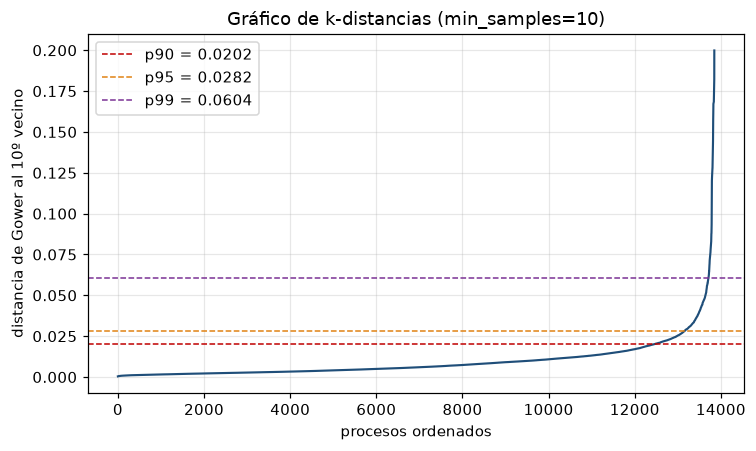

k-distancia: min=0.0004  mediana=0.0059  p90=0.0202  p99=0.0604  max=0.1999


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

MIN_SAMPLES = 10
with cron("k_distancias"):
    kd = np.partition(D, MIN_SAMPLES, axis=1)[:, MIN_SAMPLES]
    kd_ord = np.sort(kd)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(kd_ord, lw=1.4, color="#1f4e79")
for q, c in [(90, "#c00000"), (95, "#e08214"), (99, "#7b3294")]:
    v = np.percentile(kd, q)
    ax.axhline(v, ls="--", lw=1, color=c, label=f"p{q} = {v:.4f}")
ax.set_xlabel(f"procesos ordenados"); ax.set_ylabel(f"distancia de Gower al {MIN_SAMPLES}º vecino")
ax.set_title(f"Gráfico de k-distancias (min_samples={MIN_SAMPLES})")
ax.legend(); ax.grid(alpha=.3); fig.tight_layout()
fig.savefig(os.path.join(RES, "fig_kdistancias_dbscan.png"), dpi=150)
plt.show()

print(f"k-distancia: min={kd.min():.4f}  mediana={np.median(kd):.4f}  "
      f"p90={np.percentile(kd,90):.4f}  p99={np.percentile(kd,99):.4f}  max={kd.max():.4f}")

In [13]:
from sklearn.cluster import DBSCAN

EPS_GRID = [0.010, 0.015, 0.020, 0.025, 0.030, 0.040, 0.050, 0.060, 0.080, 0.100]
MS_GRID = [5, 10, 20]

filas_db = []
etq_db_por_config = {}
with cron("dbscan_barrido"):
    for ms in MS_GRID:
        for eps in EPS_GRID:
            etq = DBSCAN(eps=eps, min_samples=ms, metric="precomputed").fit_predict(D)
            ng = int(len(set(etq.tolist())) - (1 if -1 in etq else 0))
            cob = N.cobertura(etq)
            sil = np.nan
            if ng >= 2:
                sil, _, _ = N.silueta_gower(D, etq)
            filas_db.append({"min_samples": ms, "eps": eps, "grupos": ng,
                             "Cobertura": cob, "Silueta (Gower)": sil})
            etq_db_por_config[(ms, eps)] = etq
            gc.collect()

tab_db = pd.DataFrame(filas_db)
display(tab_db)

,min_samples,eps,grupos,Cobertura,Silueta (Gower)
0,5,0.010,87,87.218371,0.173397
1,5,0.015,51,93.919700,0.326904
2,5,0.020,39,96.642114,0.360073
3,5,0.025,32,97.934720,0.479412
4,5,0.030,32,98.606297,0.474477
5,5,0.040,25,99.292317,0.479103
6,5,0.050,22,99.559503,0.498903
7,5,0.060,23,99.689486,0.498808
8,5,0.080,22,99.711150,0.497000
9,5,0.100,22,99.718371,0.496963


In [14]:
# Selección: entre las configuraciones con >=2 grupos, la de mayor silueta sobre Gower.
val = tab_db.dropna(subset=["Silueta (Gower)"])
val = val[val["grupos"] >= 2]
if len(val):
    mejor = val.loc[val["Silueta (Gower)"].idxmax()]
    ms_b, eps_b = int(mejor["min_samples"]), float(mejor["eps"])
    etq_dbscan = etq_db_por_config[(ms_b, eps_b)]
    ng_b = int(mejor["grupos"])
    print(f"Mejor DBSCAN: min_samples={ms_b}  eps={eps_b}  -> {ng_b} grupos, "
          f"cobertura={mejor['Cobertura']:.2f}%, silueta={mejor['Silueta (Gower)']:.4f}")
    nota_db = (f"eps={eps_b} (k-dist), min_samples={ms_b}; k es SALIDA; "
               f"silueta medida sobre el subconjunto sin ruido "
               f"({int((etq_dbscan!=-1).sum()):,}/{n:,} procesos)")
    evaluar("DBSCAN", etq_dbscan, ng_b, nota=nota_db)
    CODO["DBSCAN"] = {ng_b: N.dispersion_intra(D, etq_dbscan)}
else:
    print("Ninguna configuración de DBSCAN produjo >=2 grupos.")
    etq_dbscan = None

Mejor DBSCAN: min_samples=20  eps=0.015  -> 17 grupos, cobertura=84.50%, silueta=0.5807


## Candidato 6 — Mezclas gaussianas (GMM)

Covarianza **completa**, selección de k por **BIC**. Se ajusta sobre la matriz codificada.

In [15]:
from sklearn.mixture import GaussianMixture

filas_gmm, etq_gmm_por_k = [], {}
CODO["GMM"] = {}
with cron("gmm_barrido"):
    for k in range(3, 11):
        t0 = time.time()
        g = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED,
                            n_init=3, reg_covar=1e-4, max_iter=300).fit(X_cod)
        etq = g.predict(X_cod)
        sil, _, ng = N.silueta_gower(D, etq)
        w = N.dispersion_intra(D, etq)
        CODO["GMM"][k] = w
        filas_gmm.append({"k": k, "BIC": g.bic(X_cod), "AIC": g.aic(X_cod),
                          "Silueta (Gower)": sil, "W(k) intra": w,
                          "convergió": g.converged_, "seg": round(time.time()-t0, 1)})
        etq_gmm_por_k[k] = etq
        print(f"   k={k}  BIC={g.bic(X_cod):,.0f}  silueta={sil:.4f}  ({time.time()-t0:.1f}s)")
        gc.collect()

tab_gmm = pd.DataFrame(filas_gmm)
display(tab_gmm)
k_gmm = int(tab_gmm.loc[tab_gmm["BIC"].idxmin(), "k"])
etq_gmm = etq_gmm_por_k[k_gmm]
k_gmm_sil = int(tab_gmm.loc[tab_gmm["Silueta (Gower)"].idxmax(), "k"])
print(f"\nk elegido por BIC (criterio del enunciado): {k_gmm}")
print(f"(k que maximizaría la silueta sería {k_gmm_sil} — se respeta el BIC)")
evaluar("GMM", etq_gmm, k_gmm,
        nota=f"covarianza completa; k por BIC (min BIC={tab_gmm['BIC'].min():,.0f}); reg_covar=1e-4")
print("Tamaño de grupos:", np.bincount(etq_gmm))

   k=3  BIC=-1,433,057  silueta=0.3871  (1.9s)


   k=4  BIC=-1,515,657  silueta=0.4195  (2.2s)


   k=5  BIC=-1,570,368  silueta=0.4534  (2.1s)


   k=6  BIC=-1,585,591  silueta=0.4083  (2.4s)


   k=7  BIC=-1,610,147  silueta=0.5200  (3.0s)


...

   k=9  BIC=-1,666,401  silueta=0.4420  (3.5s)


   k=10  BIC=-1,678,975  silueta=0.4439  (4.0s)


,k,BIC,AIC,Silueta (Gower),W(k) intra,convergió,seg
0,3,-1.433057e+06,-1.440397e+06,0.387087,1077.698600,True,1.9
1,4,-1.515657e+06,-1.525446e+06,0.419494,995.173669,True,2.2
2,5,-1.570368e+06,-1.582606e+06,0.453393,803.426029,True,2.1
3,6,-1.585591e+06,-1.600278e+06,0.408282,714.810377,True,2.4
4,7,-1.610147e+06,-1.627284e+06,0.520045,707.023061,True,3.0
5,8,-1.634755e+06,-1.654341e+06,0.457940,728.424815,True,3.5
6,9,-1.666401e+06,-1.688436e+06,0.441990,655.516709,True,3.5
7,10,-1.678975e+06,-1.703459e+06,0.443921,666.718042,True,4.0



k elegido por BIC (criterio del enunciado): 10
(k que maximizaría la silueta sería 7 — se respeta el BIC)


Tamaño de grupos: [1757 1197 1845 1156   85   80   49  515 5049 2115]


## Líneas base de control

Dos referencias triviales, medidas con exactamente las mismas métricas:
1. **Etiquetas aleatorias** (mismo k que el mejor candidato prototípico).
2. **Agrupamiento por `modalidad_contratacion`** (la categórica sola).

In [16]:
BASE_FILAS = []

def evaluar_base(nombre, etq, k_rep, nota=""):
    sil, nu, ng = N.silueta_gower(D, etq)
    db, ch = N.db_ch(X_cod, etq)
    fila = {"Algoritmo": nombre, "k usado/obtenido": k_rep, "Silueta (Gower)": sil,
            "Davies-Bouldin": db, "Calinski-Harabasz": ch,
            "Cobertura": N.cobertura(etq), "n evaluados (silueta)": nu, "Nota": nota}
    BASE_FILAS.append(fila)
    ETIQUETAS[nombre] = np.asarray(etq)
    return fila

rng = np.random.default_rng(SEED)
k_ref = k_km
etq_rand = rng.integers(0, k_ref, size=n).astype(np.int32)
evaluar_base("LÍNEA BASE: aleatoria", etq_rand, k_ref, nota=f"k={k_ref} (igual que K-Means); semilla 42")

etq_mod = cat.copy()
evaluar_base("LÍNEA BASE: por modalidad", etq_mod, len(cat_nombres),
             nota=f"{len(cat_nombres)} modalidades tras colapsar Catálogo Electrónico")

tabla7 = pd.DataFrame(BASE_FILAS)
display(tabla7)

,Algoritmo,k usado/obtenido,Silueta (Gower),Davies-Bouldin,Calinski-Harabasz,Cobertura,n evaluados (silueta),Nota
0,LÍNEA BASE: aleatoria,5,-0.008793,110.987664,0.619366,100.0,13848,k=5 (igual que K-Means); semilla 42
1,LÍNEA BASE: por modalidad,19,0.605454,1.818162,224.565708,100.0,13848,19 modalidades tras colapsar Catálogo Electrónico


## Estabilidad — 20 reejecuciones sobre submuestras del 80 %

Para cada candidato, en su k seleccionado: se reajusta sobre 20 submuestras aleatorias
del 80 % y se compara con la partición de referencia (ajuste completo) restringida a esos
mismos puntos. Se reporta el **ARI promedio** y su **desviación**.

In [17]:
def sub_D(idx):
    return D[np.ix_(idx, idx)]

def est_kproto(idx):
    return fit_kproto(k_kp, X=Xkp[idx])

def est_kmeans(idx):
    return fit_kmeans(k_km, X=X_cod[idx])

def est_jerar(idx):
    Ds = sub_D(idx)
    c = N.condensada(Ds); del Ds; gc.collect()
    Zs = linkage(c, method="average"); del c; gc.collect()
    return fcluster(Zs, k_jr, criterion="maxclust") - 1

def est_pam(idx):
    Ds = sub_D(idx)
    e, _ = N.pam(Ds, k_pam); del Ds; gc.collect()
    return e

def est_gmm(idx):
    return GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=SEED,
                           n_init=3, reg_covar=1e-4, max_iter=300).fit_predict(X_cod[idx])

def est_dbscan(idx):
    Ds = sub_D(idx)
    e = DBSCAN(eps=eps_b, min_samples=ms_b, metric="precomputed").fit_predict(Ds)
    del Ds; gc.collect()
    return e

PLAN_EST = [
    ("K-Prototypes", est_kproto, etq_kp),
    ("K-Means", est_kmeans, etq_km),
    ("Jerárquico (promedio)", est_jerar, etq_jr),
    ("K-Medoids (PAM)", est_pam, etq_pam),
    ("DBSCAN", est_dbscan, etq_dbscan),
    ("GMM", est_gmm, etq_gmm),
]

ARI = {}
with cron("estabilidad"):
    for nombre, fn, ref in PLAN_EST:
        if ref is None:
            ARI[nombre] = (np.nan, np.nan, [])
            print(f"{nombre:<24} -> no ejecutado")
            continue
        t0 = time.time()
        media, desv, lista = N.estabilidad_ari(fn, n, ref, n_rep=20, frac=0.8, seed=SEED)
        ARI[nombre] = (media, desv, lista)
        print(f"{nombre:<24} ARI = {media:.4f} ± {desv:.4f}   ({time.time()-t0:.0f}s, {len(lista)} reps)")
        gc.collect()

K-Prototypes             ARI = 0.9881 ± 0.0052   (863s, 20 reps)


K-Means                  ARI = 0.7376 ± 0.2217   (1s, 20 reps)


Jerárquico (promedio)    ARI = 0.9997 ± 0.0012   (68s, 20 reps)


K-Medoids (PAM)          ARI = 0.9921 ± 0.0042   (135s, 20 reps)


DBSCAN                   ARI = 0.9574 ± 0.0042   (27s, 20 reps)


GMM                      ARI = 0.7867 ± 0.0680   (41s, 20 reps)


In [18]:
# Estabilidad de las líneas base, con las mismas métricas
def est_rand(idx):
    return np.random.default_rng(SEED + len(idx)).integers(0, k_ref, size=len(idx))

def est_mod(idx):
    return cat[idx]

for nombre, fn, ref in [("LÍNEA BASE: aleatoria", est_rand, etq_rand),
                        ("LÍNEA BASE: por modalidad", est_mod, etq_mod)]:
    media, desv, _ = N.estabilidad_ari(fn, n, ref, n_rep=20, frac=0.8, seed=SEED)
    ARI[nombre] = (media, desv, [])
    print(f"{nombre:<28} ARI = {media:.4f} ± {desv:.4f}")

LÍNEA BASE: aleatoria        ARI = 0.0001 ± 0.0001
LÍNEA BASE: por modalidad    ARI = 1.0000 ± 0.0000


## Tabla 6 — Comparación de los seis candidatos

In [19]:
tabla6 = pd.DataFrame(RESULTADOS)
tabla6["ARI"] = tabla6["Algoritmo"].map(lambda a: ARI.get(a, (np.nan,))[0])
tabla6["ARI desv."] = tabla6["Algoritmo"].map(lambda a: ARI.get(a, (np.nan, np.nan))[1])

COLS6 = ["Algoritmo", "k usado/obtenido", "Silueta (Gower)", "Davies-Bouldin",
         "Calinski-Harabasz", "Cobertura", "ARI", "ARI desv.", "n evaluados (silueta)", "Nota"]
tabla6 = tabla6[COLS6]
tabla6.to_csv(os.path.join(RES, "tabla6_comparacion.csv"), index=False, encoding="utf-8")

pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 70)
display(tabla6.style.format({"Silueta (Gower)": "{:.4f}", "Davies-Bouldin": "{:.4f}",
                             "Calinski-Harabasz": "{:.1f}", "Cobertura": "{:.2f}%",
                             "ARI": "{:.4f}", "ARI desv.": "{:.4f}"}))
print("\nDavies-Bouldin y Calinski-Harabasz están calculados sobre la MATRIZ CODIFICADA")
print("(euclidiana), no sobre Gower. Criterio SECUNDARIO.")

,Algoritmo,k usado/obtenido,Silueta (Gower),Davies-Bouldin,Calinski-Harabasz,Cobertura,ARI,ARI desv.,n evaluados (silueta),Nota
0,K-Prototypes,3,0.2022,1.4751,4252.9,100.00%,0.9881,0.0052,13848,gamma auto=0.5000; init=Cao
1,K-Means,5,0.2156,1.0100,3902.5,100.00%,0.7376,0.2217,13848,one-hot modalidad; k-means++; n_init=10
2,Jerárquico (promedio),3,0.3987,1.0156,860.2,100.00%,0.9997,0.0012,13848,Gower precomputada; enlace promedio
3,K-Medoids (PAM),10,0.5202,2.2550,1159.1,100.00%,0.9921,0.0042,13848,BUILD + alternante; medoides = procesos reales
4,DBSCAN,17,0.5807,1.6870,1123.6,84.50%,0.9574,0.0042,11702,"eps=0.015 (k-dist), min_samples=20; k es SALIDA; silueta medida sobre el subconjunto sin ruido (11,702/13,848 procesos)"
5,GMM,10,0.4439,2.1935,1875.5,100.00%,0.7867,0.0680,13848,"covarianza completa; k por BIC (min BIC=-1,678,975); reg_covar=1e-4"



Davies-Bouldin y Calinski-Harabasz están calculados sobre la MATRIZ CODIFICADA
(euclidiana), no sobre Gower. Criterio SECUNDARIO.


In [20]:
tabla7 = pd.DataFrame(BASE_FILAS)
tabla7["ARI"] = tabla7["Algoritmo"].map(lambda a: ARI.get(a, (np.nan,))[0])
tabla7["ARI desv."] = tabla7["Algoritmo"].map(lambda a: ARI.get(a, (np.nan, np.nan))[1])
tabla7 = tabla7[COLS6]
tabla7.to_csv(os.path.join(RES, "tabla7_lineas_base.csv"), index=False, encoding="utf-8")
display(tabla7.style.format({"Silueta (Gower)": "{:.4f}", "Davies-Bouldin": "{:.4f}",
                             "Calinski-Harabasz": "{:.1f}", "Cobertura": "{:.2f}%",
                             "ARI": "{:.4f}", "ARI desv.": "{:.4f}"}))

print("\n¿Algún candidato NO supera las líneas base triviales?")
sil_rand = float(tabla7.loc[tabla7["Algoritmo"].str.contains("aleatoria"), "Silueta (Gower)"].iloc[0])
sil_mod = float(tabla7.loc[tabla7["Algoritmo"].str.contains("modalidad"), "Silueta (Gower)"].iloc[0])
print(f"   línea base aleatoria: silueta = {sil_rand:.4f}")
print(f"   línea base modalidad: silueta = {sil_mod:.4f}")
for _, r in tabla6.iterrows():
    marcas = []
    if not (r["Silueta (Gower)"] > sil_rand): marcas.append("NO supera la aleatoria")
    if not (r["Silueta (Gower)"] > sil_mod): marcas.append("NO supera la de modalidad")
    print(f"   {r['Algoritmo']:<24} {r['Silueta (Gower)']:.4f}  "
          f"{'; '.join(marcas) if marcas else 'supera ambas'}")

,Algoritmo,k usado/obtenido,Silueta (Gower),Davies-Bouldin,Calinski-Harabasz,Cobertura,ARI,ARI desv.,n evaluados (silueta),Nota
0,LÍNEA BASE: aleatoria,5,-0.0088,110.9877,0.6,100.00%,0.0001,0.0001,13848,k=5 (igual que K-Means); semilla 42
1,LÍNEA BASE: por modalidad,19,0.6055,1.8182,224.6,100.00%,1.0000,0.0000,13848,19 modalidades tras colapsar Catálogo Electrónico



¿Algún candidato NO supera las líneas base triviales?
   línea base aleatoria: silueta = -0.0088
   línea base modalidad: silueta = 0.6055
   K-Prototypes             0.2022  NO supera la de modalidad
   K-Means                  0.2156  NO supera la de modalidad
   Jerárquico (promedio)    0.3987  NO supera la de modalidad
   K-Medoids (PAM)          0.5202  NO supera la de modalidad
   DBSCAN                   0.5807  NO supera la de modalidad
   GMM                      0.4439  NO supera la de modalidad


## Regla de decisión (fijada de antemano)

1. Se descarta todo candidato con **cobertura < 90 %** o **ARI de estabilidad < 0.60**.
2. Entre los que pasan, gana la **mayor silueta sobre Gower**.
3. Diferencia < 0.02 entre los dos mejores = **empate técnico**, se resuelve por
   interpretabilidad de los centroides.

In [21]:
UMBRAL_COB, UMBRAL_ARI, UMBRAL_EMPATE = 90.0, 0.60, 0.02

descartados, admitidos = [], []
for _, r in tabla6.iterrows():
    razones = []
    if pd.isna(r["Silueta (Gower)"]):
        razones.append("sin silueta (no produjo >=2 grupos)")
    if pd.notna(r["Cobertura"]) and r["Cobertura"] < UMBRAL_COB:
        razones.append(f"cobertura {r['Cobertura']:.2f}% < 90%")
    if pd.isna(r["ARI"]) or r["ARI"] < UMBRAL_ARI:
        razones.append(f"ARI {r['ARI']:.4f} < 0.60" if pd.notna(r["ARI"]) else "ARI no disponible")
    (descartados if razones else admitidos).append((r, razones))

print("=" * 78)
print("DESCARTADOS")
print("=" * 78)
if not descartados:
    print("   (ninguno)")
for r, razones in descartados:
    print(f"   {r['Algoritmo']:<24} -> {'; '.join(razones)}")

print()
print("=" * 78)
print("ADMITIDOS (ordenados por silueta sobre Gower)")
print("=" * 78)
adm = sorted(admitidos, key=lambda x: -x[0]["Silueta (Gower)"])
for r, _ in adm:
    print(f"   {r['Algoritmo']:<24} silueta={r['Silueta (Gower)']:.4f}  "
          f"cobertura={r['Cobertura']:.2f}%  ARI={r['ARI']:.4f}")

EMPATE = False
if len(adm) == 0:
    GANADOR = None
    print("\nNINGÚN candidato pasa los filtros.")
else:
    GANADOR = adm[0][0]["Algoritmo"]
    if len(adm) >= 2:
        d = adm[0][0]["Silueta (Gower)"] - adm[1][0]["Silueta (Gower)"]
        print(f"\nDiferencia entre los dos mejores: {d:.4f}")
        if d < UMBRAL_EMPATE:
            EMPATE = True
            print(f"EMPATE TÉCNICO (< {UMBRAL_EMPATE}) entre '{adm[0][0]['Algoritmo']}' "
                  f"y '{adm[1][0]['Algoritmo']}' -> se resuelve por interpretabilidad de centroides.")
    print(f"\nGANADOR PROVISIONAL: {GANADOR}")

DESCARTADOS
   DBSCAN                   -> cobertura 84.50% < 90%

ADMITIDOS (ordenados por silueta sobre Gower)
   K-Medoids (PAM)          silueta=0.5202  cobertura=100.00%  ARI=0.9921
   GMM                      silueta=0.4439  cobertura=100.00%  ARI=0.7867
   Jerárquico (promedio)    silueta=0.3987  cobertura=100.00%  ARI=0.9997
   K-Means                  silueta=0.2156  cobertura=100.00%  ARI=0.7376
   K-Prototypes             silueta=0.2022  cobertura=100.00%  ARI=0.9881

Diferencia entre los dos mejores: 0.0763

GANADOR PROVISIONAL: K-Medoids (PAM)


In [22]:
# Si hay empate técnico, comparar interpretabilidad de los centroides de los dos mejores.
if EMPATE:
    print("Perfiles de los dos empatados (medias por grupo, variables originales):\n")
    for cand, _ in adm[:2]:
        nom = cand["Algoritmo"]; e = ETIQUETAS[nom]
        p = df.assign(_g=e).groupby("_g")[N.NUMERICAS].mean()
        p["procesos"] = df.assign(_g=e).groupby("_g").size()
        p["modalidad dominante"] = df.assign(_g=e).groupby("_g")[N.CATEGORICA].agg(
            lambda s: s.value_counts().index[0])
        print(f"--- {nom} ---")
        display(p.round(3))
        # dispersión relativa entre centroides: cuanto mayor, más separados/legibles
        z = (p[N.NUMERICAS] - p[N.NUMERICAS].mean()) / p[N.NUMERICAS].std(ddof=0).replace(0, 1)
        print(f"    separación media de centroides (|z| medio): {z.abs().to_numpy().mean():.3f}")
        print(f"    modalidades dominantes distintas: {p['modalidad dominante'].nunique()} "
              f"de {len(p)} grupos\n")
else:
    print("Sin empate técnico: gana directamente la mayor silueta.")

Sin empate técnico: gana directamente la mayor silueta.


## Tabla 8 — Perfiles de los grupos del ganador

La columna **Lectura de negocio** se deja vacía a propósito.

In [23]:
etq_gan = ETIQUETAS[GANADOR]
dfg = df.assign(_g=etq_gan)
dfg = dfg[dfg["_g"] != -1]

perf = dfg.groupby("_g").agg(
    Procesos=("ocid", "size"),
    **{"Similitud semántica": ("sim_semantica_tfidf", "mean"),
       "Coincid. CPC": ("cpc_match_score", "mean"),
       "Desv. presupuesto": ("desviacion_presupuesto", "mean"),
       "Distancia (km)": ("distancia_geografica_km", "mean")}
).reset_index().rename(columns={"_g": "Grupo"})

dom = dfg.groupby("_g")[N.CATEGORICA].agg(lambda s: s.value_counts().index[0])
perf["Modalidad dominante"] = perf["Grupo"].map(dom)
perf["Lectura de negocio"] = ""

tabla8 = perf[["Grupo", "Procesos", "Similitud semántica", "Coincid. CPC",
               "Desv. presupuesto", "Distancia (km)", "Modalidad dominante",
               "Lectura de negocio"]]
tabla8.to_csv(os.path.join(RES, "tabla8_perfiles.csv"), index=False, encoding="utf-8")
print(f"Ganador: {GANADOR}   (k = {len(tabla8)} grupos)")
display(tabla8.style.format({"Similitud semántica": "{:.4f}", "Coincid. CPC": "{:.4f}",
                             "Desv. presupuesto": "{:.4f}", "Distancia (km)": "{:.1f}"}))

Ganador: K-Medoids (PAM)   (k = 10 grupos)


,Grupo,Procesos,Similitud semántica,Coincid. CPC,Desv. presupuesto,Distancia (km),Modalidad dominante,Lectura de negocio
0,0,1082,0.0063,0.0140,2.4129,167.4,Cotización,
1,1,363,0.0062,0.0000,0.5121,217.9,Licitación de Seguros,
2,2,1891,0.0038,0.0076,0.1479,187.8,Menor Cuantía,
3,3,388,0.0085,0.0382,0.5559,143.2,Contratos entre Entidades Públicas o sus subsidiarias,
4,4,351,0.0042,0.0034,-1.6346,218.1,Comunicación Social – Contratación Directa,
5,5,553,0.0144,0.0720,-0.1886,124.1,Bienes y Servicios únicos,
6,6,2257,0.0996,0.9962,0.2469,190.7,Subasta Inversa Electrónica,
7,7,2986,0.0064,0.0001,0.1831,184.5,Subasta Inversa Electrónica,
8,8,1016,0.0063,0.0002,-0.7788,208.4,Contratacion directa,
9,9,2961,0.0096,0.2548,0.2494,174.8,Subasta Inversa Electrónica,


## Tabla 9 — Atípicos por grupo (Isolation Forest, `contamination=0.05`)

In [24]:
from sklearn.ensemble import IsolationForest

filas9 = []
with cron("isolation_forest"):
    for g in sorted(dfg["_g"].unique()):
        sub = dfg[dfg["_g"] == g]
        Xg = sub[N.NUMERICAS].to_numpy(dtype=np.float64)
        if len(sub) < 10:
            filas9.append({"Grupo": g, "Procesos": len(sub), "Atípicos": np.nan,
                           "%": np.nan, "Variable que más se aleja": "grupo < 10 procesos"})
            continue
        iso = IsolationForest(contamination=0.05, random_state=SEED, n_estimators=200)
        pred = iso.fit_predict(Xg)
        out = pred == -1
        # variable que más se aleja: mayor |media_atípicos - media_grupo| en unidades sigma
        mu, sd = Xg.mean(0), Xg.std(0)
        sd[sd == 0] = 1.0
        desv = np.abs((Xg[out].mean(0) - mu) / sd)
        var = N.NUMERICAS[int(np.argmax(desv))]
        filas9.append({"Grupo": g, "Procesos": len(sub), "Atípicos": int(out.sum()),
                       "%": round(100.0 * out.sum() / len(sub), 2),
                       "Variable que más se aleja": f"{var} ({desv.max():.2f}σ)"})

tabla9 = pd.DataFrame(filas9)
tabla9.to_csv(os.path.join(RES, "tabla9_atipicos.csv"), index=False, encoding="utf-8")
display(tabla9)

,Grupo,Procesos,Atípicos,%,Variable que más se aleja
0,0,1082,55,5.08,cpc_match_score (1.72σ)
1,1,363,19,5.23,actividad_cpc_comprador (2.17σ)
2,2,1891,95,5.02,cpc_match_score (1.72σ)
3,3,388,20,5.15,actividad_cpc_comprador (1.95σ)
4,4,351,18,5.13,cpc_match_score (2.44σ)
5,5,553,28,5.06,cpc_match_score (2.84σ)
6,6,2257,113,5.01,cpc_match_score (2.33σ)
7,7,2986,150,5.02,actividad_cpc_comprador (2.12σ)
8,8,1016,51,5.02,actividad_cpc_comprador (2.05σ)
9,9,2961,148,5.00,actividad_cpc_comprador (1.82σ)


## Figuras

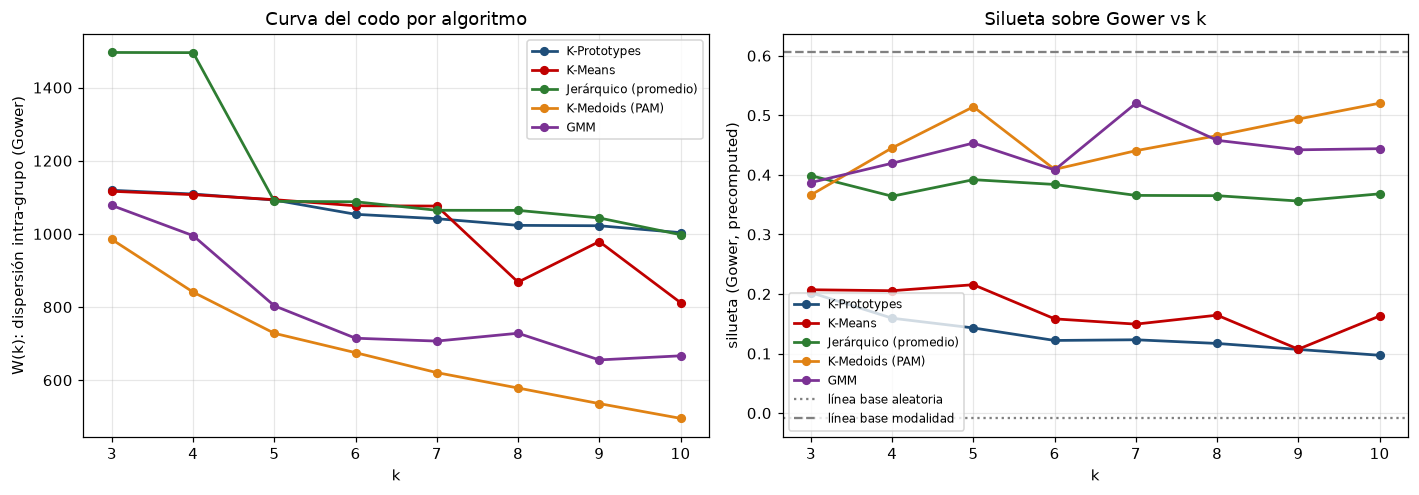

In [25]:
# --- Curva del codo por algoritmo (dispersión intra-grupo W(k) sobre Gower)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
colores = {"K-Prototypes": "#1f4e79", "K-Means": "#c00000", "Jerárquico (promedio)": "#2e7d32",
           "K-Medoids (PAM)": "#e08214", "GMM": "#7b3294", "DBSCAN": "#795548"}
for nom, dd in CODO.items():
    if len(dd) < 2:
        continue
    ks = sorted(dd); axes[0].plot(ks, [dd[k] for k in ks], "o-", label=nom,
                                  color=colores.get(nom), lw=1.8, ms=5)
axes[0].set_xlabel("k"); axes[0].set_ylabel("W(k): dispersión intra-grupo (Gower)")
axes[0].set_title("Curva del codo por algoritmo"); axes[0].grid(alpha=.3); axes[0].legend(fontsize=8)

for nom, tab in [("K-Prototypes", tab_kp), ("K-Means", tab_km),
                 ("Jerárquico (promedio)", tab_jr), ("K-Medoids (PAM)", tab_pam)]:
    axes[1].plot(tab["k"], tab["Silueta (Gower)"], "o-", label=nom, color=colores.get(nom), lw=1.8, ms=5)
axes[1].plot(tab_gmm["k"], tab_gmm["Silueta (Gower)"], "o-", label="GMM", color=colores["GMM"], lw=1.8, ms=5)
axes[1].axhline(sil_rand, ls=":", color="gray", label="línea base aleatoria")
axes[1].axhline(sil_mod, ls="--", color="gray", label="línea base modalidad")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silueta (Gower, precomputed)")
axes[1].set_title("Silueta sobre Gower vs k"); axes[1].grid(alpha=.3); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(RES, "fig_codo_por_algoritmo.png"), dpi=150)
plt.show()

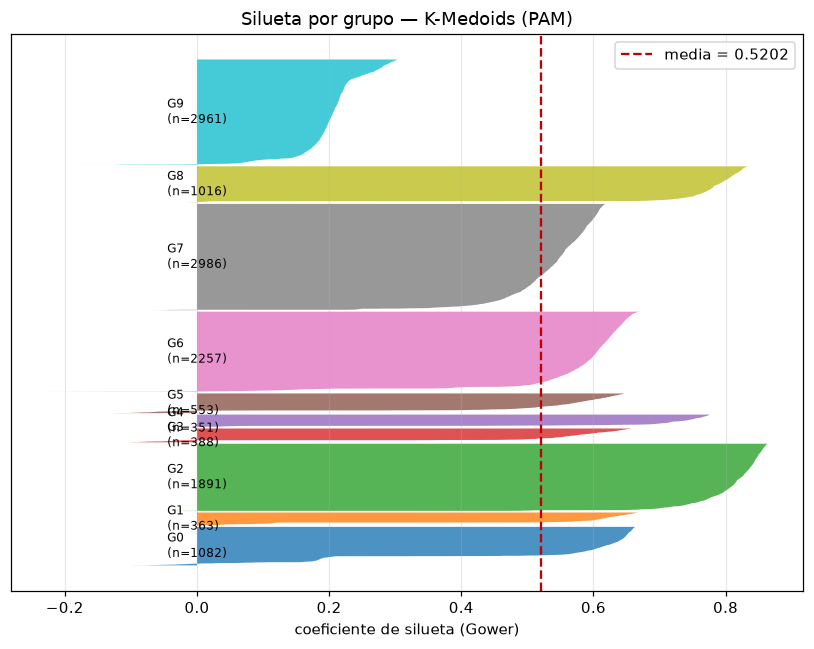

silueta media del ganador = 0.5202


In [26]:
# --- Silueta por grupo del ganador
from sklearn.metrics import silhouette_samples

mask = etq_gan != -1
idx = np.flatnonzero(mask)
Dg = D if idx.size == n else D[np.ix_(idx, idx)]
sv = silhouette_samples(Dg, etq_gan[mask], metric="precomputed")
if Dg is not D:
    del Dg; gc.collect()
sil_gan = float(sv.mean())

fig, ax = plt.subplots(figsize=(7.5, 6))
y = 10
for g in sorted(np.unique(etq_gan[mask])):
    vals = np.sort(sv[etq_gan[mask] == g])
    ax.fill_betweenx(np.arange(y, y + len(vals)), 0, vals, alpha=.8)
    ax.text(-0.045, y + len(vals) / 2, f"G{g}\n(n={len(vals)})", fontsize=8, va="center")
    y += len(vals) + 40
ax.axvline(sil_gan, color="#c00000", ls="--", lw=1.5, label=f"media = {sil_gan:.4f}")
ax.set_xlabel("coeficiente de silueta (Gower)"); ax.set_yticks([])
ax.set_title(f"Silueta por grupo — {GANADOR}"); ax.legend(); ax.grid(alpha=.3, axis="x")
fig.tight_layout(); fig.savefig(os.path.join(RES, "fig_silueta_por_grupo_ganador.png"), dpi=150)
plt.show()
print(f"silueta media del ganador = {sil_gan:.4f}")

submuestra MDS: 2,000 de 13,848 procesos (14.4%), estratificada por grupo


C:\Users\JuanR\proyecto-ia-sercop\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\JuanR\proyecto-ia-sercop\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


MDS: stress=4200.77  (84.87 s)


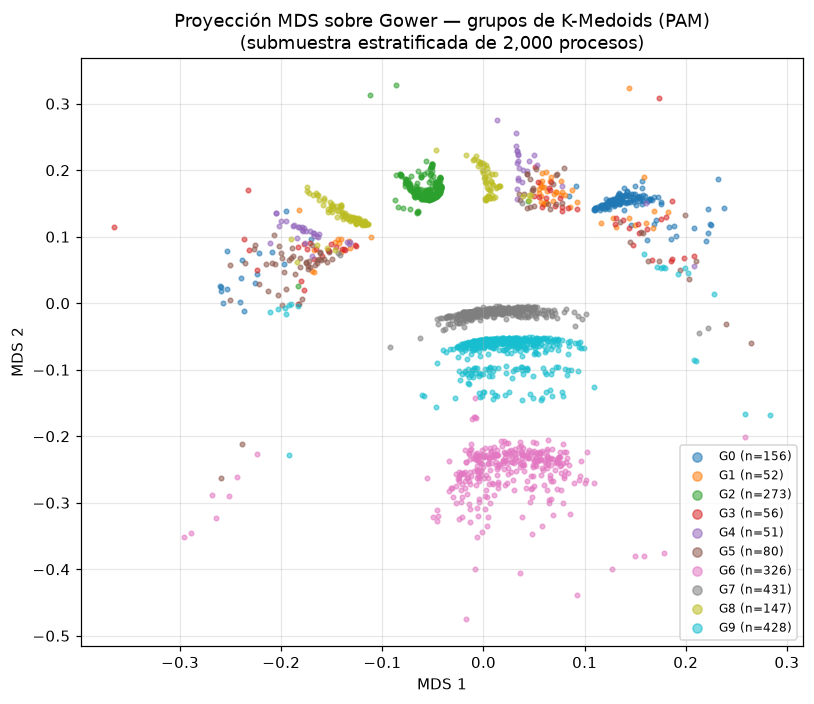

In [27]:
# --- Proyección 2D: MDS sobre la matriz de Gower.
# MDS/SMACOF es O(n^2) por iteración; con n=13.848 no es viable en tiempo razonable.
# Se usa una SUBMUESTRA ESTRATIFICADA por grupo del ganador. Es sólo una figura:
# ninguna métrica de la tabla 6 depende de ella.
from sklearn.manifold import MDS

N_MDS = 2000
rng = np.random.default_rng(SEED)
idx_all = np.flatnonzero(etq_gan != -1)
etq_all = etq_gan[idx_all]
sel = []
for g in np.unique(etq_all):
    ig = idx_all[etq_all == g]
    cuota = max(20, int(round(N_MDS * len(ig) / len(idx_all))))
    cuota = min(cuota, len(ig))
    sel.append(rng.choice(ig, size=cuota, replace=False))
sel = np.sort(np.concatenate(sel))
print(f"submuestra MDS: {len(sel):,} de {len(idx_all):,} procesos "
      f"({100*len(sel)/len(idx_all):.1f}%), estratificada por grupo")

Dm = D[np.ix_(sel, sel)].astype(np.float64)
with cron("mds"):
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED,
              n_init=4, max_iter=300, normalized_stress=False)
    P = mds.fit_transform(Dm)
del Dm; gc.collect()
print(f"MDS: stress={mds.stress_:.2f}  ({cron.t['mds']} s)")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for g in sorted(np.unique(etq_gan[sel])):
    m = etq_gan[sel] == g
    ax.scatter(P[m, 0], P[m, 1], s=9, alpha=.55, label=f"G{g} (n={m.sum()})")
ax.set_title(f"Proyección MDS sobre Gower — grupos de {GANADOR}\n"
             f"(submuestra estratificada de {len(sel):,} procesos)")
ax.set_xlabel("MDS 1"); ax.set_ylabel("MDS 2"); ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(os.path.join(RES, "fig_mds_grupos_ganador.png"), dpi=150)
plt.show()

## Asignabilidad — cómo se asignaría un proveedor nuevo

Prototipo (K-Prototypes, K-Means, GMM) y medoide (K-Medoids) son directos.
Jerárquico y DBSCAN no producen prototipo: se usa el **centroide empírico** del grupo.

In [28]:
ASIGNA = {
 "K-Prototypes": "Directa por PROTOTIPO: distancia mixta (euclidiana en las numéricas + "
                 "desacuerdo x gamma en la modalidad) al prototipo de cada grupo; gana el mínimo.",
 "K-Means": "Directa por PROTOTIPO: distancia euclidiana al centroide en el espacio codificado "
            "(numéricas z-score + one-hot de modalidad).",
 "Jerárquico (promedio)": "SIN prototipo nativo. Se calcula el CENTROIDE EMPÍRICO de cada grupo "
                          "(media de las numéricas + modalidad modal) y se asigna por Gower al más cercano.",
 "K-Medoids (PAM)": "Directa por MEDOIDE: distancia de Gower a cada medoide, que es un proceso real "
                    "del conjunto; gana el mínimo.",
 "DBSCAN": "SIN prototipo nativo y con ruido. Se calcula el CENTROIDE EMPÍRICO de cada grupo real "
           "y se asigna por Gower; si la distancia supera eps, el proceso queda como ruido.",
 "GMM": "Directa por PROTOTIPO probabilístico: se evalúa la densidad de cada componente y se asigna "
        "al de mayor probabilidad posterior (predict_proba).",
}
asig = pd.DataFrame([{"Algoritmo": a, "Asignación de un proveedor nuevo": t} for a, t in ASIGNA.items()])
asig.to_csv(os.path.join(RES, "asignabilidad.csv"), index=False, encoding="utf-8")
pd.set_option("display.max_colwidth", 200)
display(asig)

,Algoritmo,Asignación de un proveedor nuevo
0,K-Prototypes,Directa por PROTOTIPO: distancia mixta (euclidiana en las numéricas + desacuerdo x gamma en la modalidad) al prototipo de cada grupo; gana el mínimo.
1,K-Means,Directa por PROTOTIPO: distancia euclidiana al centroide en el espacio codificado (numéricas z-score + one-hot de modalidad).
2,Jerárquico (promedio),SIN prototipo nativo. Se calcula el CENTROIDE EMPÍRICO de cada grupo (media de las numéricas + modalidad modal) y se asigna por Gower al más cercano.
3,K-Medoids (PAM),"Directa por MEDOIDE: distancia de Gower a cada medoide, que es un proceso real del conjunto; gana el mínimo."
4,DBSCAN,"SIN prototipo nativo y con ruido. Se calcula el CENTROIDE EMPÍRICO de cada grupo real y se asigna por Gower; si la distancia supera eps, el proceso queda como ruido."
5,GMM,Directa por PROTOTIPO probabilístico: se evalúa la densidad de cada componente y se asigna al de mayor probabilidad posterior (predict_proba).


## Log de ejecución

In [29]:
lineas = []
lineas.append("LOG DE EJECUCIÓN — comparación de seis algoritmos de agrupamiento")
lineas.append("Proyecto final de IA — ESPOL CCPG1044 Grupo #3 — SERCOP/OCDS")
lineas.append(f"Generado: {time.strftime('%Y-%m-%d %H:%M:%S')}")
lineas.append("")
lineas.append("VERSIONES DE LIBRERÍAS")
for k, v in VERSIONES.items():
    lineas.append(f"   {k:<16} {v}")
lineas.append(f"   {'scikit-learn-extra':<16} {SKEXTRA}")
lineas.append("")
lineas.append("SEMILLA: random_state = 42 en todos los ajustes")
lineas.append("")
lineas.append("DATOS")
lineas.append(f"   archivos ................ data/2024.jsonl.gz, 2025.jsonl.gz, 2026.jsonl.gz")
lineas.append(f"   procesos leídos ......... {inv['lineas_leidas']:,}")
lineas.append(f"   procesos activos ........ {inv['activos_tender_status']:,}")
lineas.append(f"   filas de la matriz ...... {n:,} x {len(N.NUMERICAS)+1}")
lineas.append(f"   matriz codificada ....... {X_cod.shape[0]:,} x {X_cod.shape[1]}")
lineas.append(f"   Gower ................... {D.shape[0]:,}^2 float32 = {D.nbytes/1024**3:.3f} GB")
lineas.append(f"   proveedor consultante ... {inv['proveedor_consultante']['nombre']} "
              f"({inv['proveedor_consultante']['id']})")
lineas.append("")
lineas.append("TIEMPOS (segundos)")
for k, v in cron.t.items():
    lineas.append(f"   {k:<24} {v:>9.2f}")
lineas.append(f"   {'TOTAL medido':<24} {sum(cron.t.values()):>9.2f}")
lineas.append("")
lineas.append("k SELECCIONADO POR ALGORITMO")
lineas.append(f"   K-Prototypes ............ k={k_kp} (máx. silueta Gower)")
lineas.append(f"   K-Means ................. k={k_km} (máx. silueta Gower)")
lineas.append(f"   Jerárquico .............. k={k_jr} (máx. silueta Gower)")
lineas.append(f"   K-Medoids (PAM) ......... k={k_pam} (máx. silueta Gower)")
lineas.append(f"   DBSCAN .................. {ng_b} grupos OBTENIDOS (eps={eps_b}, min_samples={ms_b})")
lineas.append(f"   GMM ..................... k={k_gmm} (mín. BIC)")
lineas.append("")
lineas.append("DESVIACIONES Y LIMITACIONES DECLARADAS")
lineas.append("   1. scikit-learn-extra no importa con numpy 2.x:")
lineas.append(f"      {SKEXTRA}")
lineas.append("      -> PAM implementado en scripts/nucleo.py sobre la matriz de Gower")
lineas.append("         (init BUILD + refinamiento alternante; el SWAP exhaustivo de PAM clásico")
lineas.append("          es O(k(n-k)^2) por iteración e intratable con n=13.848).")
lineas.append("   2. La matriz de Gower se guarda en float32 (0.71 GB) en vez de float64 (1.43 GB)")
lineas.append("      por la memoria física disponible en la máquina.")
lineas.append("   3. La proyección MDS se calcula sobre una submuestra estratificada de "
              f"{len(sel):,} procesos:")
lineas.append("      SMACOF es O(n^2) por iteración y no es viable con n=13.848. Es sólo una figura;")
lineas.append("      ninguna métrica de la tabla 6 depende de ella.")
lineas.append("   4. Davies-Bouldin y Calinski-Harabasz se calculan sobre la matriz CODIFICADA")
lineas.append("      (euclidiana), no sobre Gower. Criterio secundario, así etiquetado.")
lineas.append("   5. 812 procesos activos (5,5%) quedaron fuera de la matriz por datos faltantes")
lineas.append("      (508 sin ítems, 304 sin provincia del comprador). No se imputó nada.")
lineas.append("   6. 'Catálogo Electrónico' no aparece entre los procesos activos: la regla de")
lineas.append("      colapsar convenios se aplicó pero resulta inocua sobre esta matriz.")
for a in avisos_kp:
    lineas.append(f"   7. Aviso de kmodes: {a}")
lineas.append("")
lineas.append("SALIDAS")
for f in ["tabla6_comparacion.csv", "tabla7_lineas_base.csv", "tabla8_perfiles.csv",
          "tabla9_atipicos.csv", "asignabilidad.csv", "matriz_procesos.csv",
          "fig_codo_por_algoritmo.png", "fig_silueta_por_grupo_ganador.png",
          "fig_mds_grupos_ganador.png", "fig_kdistancias_dbscan.png"]:
    p = os.path.join(RES, f)
    lineas.append(f"   {'OK ' if os.path.exists(p) else 'FALTA'} resultados/{f}")
lineas.append("")
lineas.append("RESULTADO")
lineas.append(f"   GANADOR: {GANADOR}  (silueta Gower = "
              f"{float(tabla6.loc[tabla6['Algoritmo']==GANADOR,'Silueta (Gower)'].iloc[0]):.4f})")
for r, razones in descartados:
    lineas.append(f"   DESCARTADO: {r['Algoritmo']} -> {'; '.join(razones)}")

txt = "\n".join(lineas)
with open(os.path.join(RES, "log_ejecucion.txt"), "w", encoding="utf-8") as f:
    f.write(txt + "\n")
print(txt)

LOG DE EJECUCIÓN — comparación de seis algoritmos de agrupamiento
Proyecto final de IA — ESPOL CCPG1044 Grupo #3 — SERCOP/OCDS
Generado: 2026-07-29 23:21:36

VERSIONES DE LIBRERÍAS
   python           3.11.15
   numpy            2.4.6
   pandas           3.0.5
   scipy            1.17.1
   scikit-learn     1.9.0
   kmodes           0.12.2
   matplotlib       3.11.1
   so               Windows 10
   scikit-learn-extra ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

SEMILLA: random_state = 42 en todos los ajustes

DATOS
   archivos ................ data/2024.jsonl.gz, 2025.jsonl.gz, 2026.jsonl.gz
   procesos leídos ......... 90,076
   procesos activos ........ 14,660
   filas de la matriz ...... 13,848 x 6
   matriz codificada ....... 13,848 x 24
   Gower ................... 13,848^2 float32 = 0.714 GB
   proveedor consultante ... ROCHE ECUADOR S.A. (EC-RUC-1790475689001-5192)

TIEMPOS (segundos)
   preprocesamie

---
Todas las tablas y figuras quedan en `resultados/`. Las cifras de este notebook son las
producidas por esta ejecución; no hay valores estimados ni rellenados a mano.